# Двулучепреломление

In [217]:
import math
import numpy as np
import numpy.typing as npt
from typing import Union
import matplotlib.pyplot as plt
# Используем Union, чтобы функция принимала и одиночные числа (float),  и массивы (NDArray)
Numeric = Union[float, npt.NDArray[np.float64]]

## Функции с основными формулами

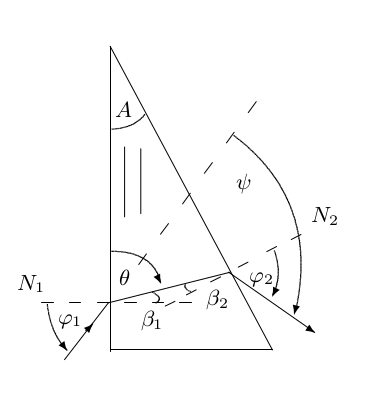

$$
\alpha = A
$$
$$
\varphi_2 = \alpha - \varphi_1 + \psi
$$


### Расчет показателя преломления по углам падающего и преломлённого лучей

$$
n = \frac{\sqrt{\sin^2(\varphi_1) + \sin^2(\varphi_2 ) + 2 \sin(\varphi_1) \sin(\varphi_2 ) \cos(\alpha)}}{\sin(\alpha)}
$$

In [218]:
def refractive_index(phi1: Numeric, psi: Numeric, alpha: float) -> Numeric:
    phi2 = alpha - phi1 + psi
    numerator = np.sqrt(
        np.sin(phi1)**2 + 
        np.sin(phi2)**2 + 
        2 * np.sin(phi1) * np.sin(phi2) * np.cos(alpha)
    )
    
    return numerator / np.sin(alpha)



$$\cos(\theta) = \frac{\sin(\varphi_1)}{n}$$


In [219]:
def cos_theta(phi1: Numeric, n: Numeric) -> Numeric:
    return np.sin(phi1) / n

### Ошибка определения показателя преломления
$$
\sigma_n = \frac{1}{2n \sin^2(\alpha)}\sqrt{
        \sigma^2_{\varphi_1} \left( sin(2\varphi_1) - \sin(2\varphi_2) - 2 \cos(a)\sin(\varphi_1 - \varphi_2) \right)^2 
    + 
    \sigma^2_\psi \left( 
        2\sin(2\varphi_2) 
        + 
        2\cos(\alpha)\sin(\varphi_1)\cos(\varphi_2) 
    \right)^2}
$$

In [220]:
def n_err(
    phi1: Numeric, psi: Numeric, n: Numeric, 
    alpha: float, phi1_err: float, psi_err: float
    ):
    phi2 = alpha - phi1 + psi
    coeff = 1 / (2*n*(np.sin(alpha)**2))
    
    s1 = np.sin(2 * phi1) - np.sin(2 * phi2) - 2*np.cos(alpha) * np.sin(phi1 - phi2)
    s2 = np.sin(2 * phi2) + np.cos(alpha) * np.sin(phi1) * np.cos(phi2)
    
    return coeff * np.sqrt((phi1_err * s1)**2 + (psi_err*s2)**2)

In [221]:
def average(n: Numeric, sigma_n: Numeric):
    """calculating no as a weighted average"""
    weights = sigma_n**(-2)
    # weighted average
    sum_ = (n * weights).sum()
    weight = weights.sum()
    no = sum_ / weight
    noErr = np.sqrt(1 / weight)
    return no, noErr

## Построение графиков

### График исходных углов

In [222]:
# TODO: При формлении отчета подпишите оси и графики
def plot_raw(phi1, psio, psie):  
    plt.plot(phi1, psio, ".")
    plt.plot(phi1, psie, ".")

# Анализ данных

 Задание 1. Реализуйте функцию `fit_line` которая ищет параметры прямой и статистические параметры характеризующие качество аппроксимации. Функция принимает набора точек x,y и погрешность y, должна возвращать параметры прямой, величину хи-квадрат и матрицу ковариаций для найденных параметров. При расчете параметрево прямой по МНК, учитывайте переданные ошибки 

In [223]:
def fit_line(x: Numeric, y: Numeric, sigma_y: Numeric):
    # def fit_line(x: np.ndarray, y: np.ndarray, sigma_y: np.ndarray) -> Tuple[float, float, float, np.ndarray]:

    # Веса: w = 1/σ²
    inv_sigma2 = 1.0 / (sigma_y ** 2)
    
    # Матрица системы нормальных уравнений M = A^T W A
    m = np.zeros((2, 2))
    m[0, 0] = np.sum(x**2 * inv_sigma2)  # Σ(x²/σ²)
    m[0, 1] = np.sum(x * inv_sigma2)     # Σ(x/σ²)
    m[1, 0] = m[0, 1]                    # симметричный элемент
    m[1, 1] = np.sum(inv_sigma2)         # Σ(1/σ²)
    
    # Правая часть системы: B = A^T W y
    b0 = np.sum(x * y * inv_sigma2)     # Σ(x*y/σ²)
    b1 = np.sum(y * inv_sigma2)         # Σ(y/σ²)
    
    # Решение системы: θ = M⁻¹ B
    det = m[0, 0] * m[1, 1] - m[0, 1] * m[1, 0]
    cov = np.zeros((2, 2))  # ковариационная матрица = M⁻¹
    cov[0, 0] = m[1, 1] / det
    cov[0, 1] = -m[0, 1] / det
    cov[1, 0] = -m[1, 0] / det
    cov[1, 1] = m[0, 0] / det
    
    # Параметры прямой: θ = [k, b]^T
    k = cov[0, 0] * b0 + cov[0, 1] * b1  # наклон
    b = cov[1, 0] * b0 + cov[1, 1] * b1  # сдвиг
    
    # Вычисление χ² = Σ[(y - kx - b)²/σ²]
    y_model = k * x + b
    chi2 = np.sum(((y - y_model) ** 2) * inv_sigma2)
    
    # return b, k, chi2, cov
    # y = k*x + b
    # sigma - Y errors
    # cov - covariation matrix
    # chi2 - chi2 без деления на число степеней свободы
    m = np.zeros((2,2))
    invSigma2 = 1/sigma_y**2

    b0 = (y * x * invSigma2).sum();
    b1 = (y * invSigma2).sum();
    m[0][0] = ((x**(2)) * invSigma2).sum();
    m[0][1] = (x * invSigma2).sum();
    m[1][0] = m[0][1];
    m[1][1] = invSigma2.sum();
    det = m[0][0] * m[1][1] - m[1][0] * m[0][1];

    mInv = np.zeros((2,2)) # covariance matrix

    mInv[0][0] = m[1][1] / det;
    mInv[0][1] = -m[1][0] / det;
    mInv[1][0] = -m[0][1] / det;
    mInv[1][1] = m[0][0] / det;

    slope = mInv[0][0] * b0 + mInv[0][1] * b1;
    base = mInv[1][0] * b0 + mInv[1][1] * b1;

    chi2 = ((y**2) * invSigma2).sum() + (slope**2) * m[0][0] + (base**2) * m[1][1] - 2 * slope * b0 - 2 * base * b1 + 2 * slope * base * m[0][1];
    return base, slope, chi2, mInv

## Измерения

In [224]:
# Определите угол при верние призмы
alpha = 38

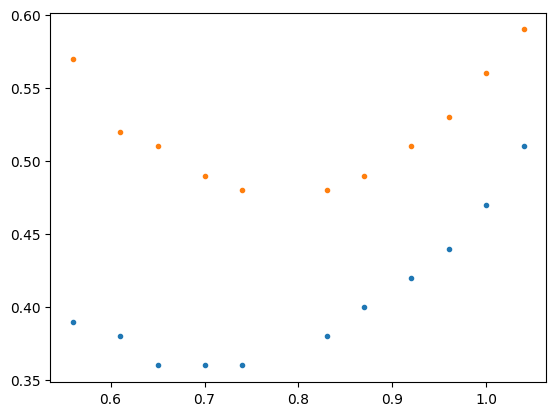

In [225]:
# Задайте ошибки измерений
phi1_err = 0.5
psio_err = 0.5
psie_err = 0.5

# Серия измерений (в случае не удачной серии, создай копию ячейки, не удаляйте плохие серии)
phi1 = np.array([0.56, 0.61, 0.65, 0.70, 0.74, 0.83, 0.87, 0.92, 0.96, 1.00, 1.04])
psi1 = np.array([0.39 ,0.38, 0.36, 0.36, 0.36, 0.38, 0.40, 0.42, 0.44, 0.47, 0.51])
psi2 = np.array([0.57, 0.52, 0.51, 0.49, 0.48, 0.48, 0.49, 0.51, 0.53, 0.56, 0.59])

# Проведите необходимые преобразования над данными (перевод в радианы, деление двойных углов, вычитание 180 градусов)
# phi1 = ...
# psi1 = ...
# psi2 = ...

# Определите какие из лучей соответсвуют обыкновенной и необыкновенной волнам
psio = psi1
psie = psi2 

plot_raw(phi1, psio, psie)

[0.17453293 0.26179939 0.34906585 0.43633231 0.52359878 0.61086524
 0.6981317  0.78539816 0.87266463 0.95993109 1.04719755 1.13446401
 1.22173048]


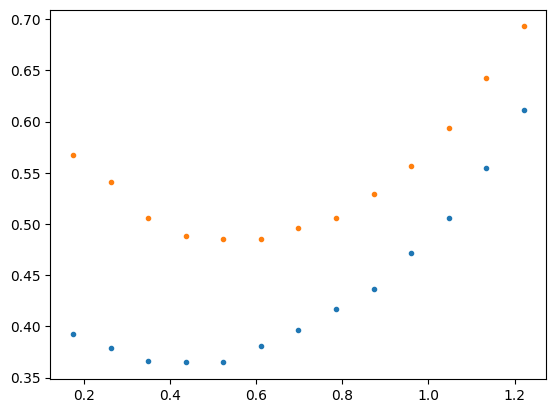

In [226]:
# Тестовые данные
# phi1 = [35, 37.5, 40, 42.5, 47.5, 50, 52.5, 55, 57.5, 60]
# psio = [22.5, 21.7, 21, 20.9, 21.8, 22.7, 23.9, 25, 27, 29]
# psie = [32.5, 31, 29, 28, 27.8, 28.4, 29, 30.3, 31.9, 34]

phi1 = []
psio = []
psie = []

alpha = math.radians(38)
phi1_err = math.radians(0.25)
psio_err = math.radians(0.25)
psie_err = math.radians(0.25)

with open("data.txt") as fin:
    for indx, line in enumerate(fin.readlines()):
        if indx == 0:
            continue
        line = line.lstrip().split("\t")
        phi1.append(float(line[0]))
        psio.append(float(line[1]))
        psie.append(float(line[2]))

# plot_raw(phi1, psio, psie)
phi1 = np.radians(phi1)
psio = np.radians(psio)
psie = np.radians(psie)
plot_raw(phi1, psio, psie)
print(phi1)



### Калибровка по обыкновенной волне

Задание 2: Используя функцию `calibrate` проверерьте качетсво измерений, пользуясь тем свойством что для обыкновенной волны ожидается постоянный показатель преломления

In [ ]:
def calibrate(phi1: Numeric, psi: Numeric, a: float, phi1_err: float, psi_err: float):
    phi1 = np.array(phi1)
    psi = np.array(psi)
    
    n_o = refractive_index(phi1, psi, a)
    sigma_n_o = n_err(phi1, psi, n_o, a, phi1_err, psi_err) 
    cos_theta_o = cos_theta(phi1, n_o)
    max_cos_2 = cos_theta_o.max()**2
    ndf = phi1.size - 2
    b, k, chi2, _ = fit_line(cos_theta_o, n_o, sigma_n_o)
    print(b, k, chi2, _)
    if abs(k) >= 0.02:
        print("Плохая калибровка!")
    if chi2 / ndf < 0.5:
        print("Ошибки завышены!")
    elif chi2 / ndf > 2:
        print("Ошибки занижены!")
    noConst, noErr = average(n_o, sigma_n_o)


    # Plot data and fit (
    plt.errorbar(phi1, n_o, yerr=sigma_n_o, fmt='.')
    phi1_s = np.linspace(phi1.min(), phi1.max(), 100)
    plt.plot(phi1_s, k*phi1_s + b)
    plt.hlines(noConst, phi1.min(), phi1.max(), "r")
    return 
    

1.4517243857604107 0.21359278830847828 38.68662668790785 [[ 6.46687944e-05 -2.59972658e-05]
 [-2.59972658e-05  1.19029107e-05]]
Плохая калибровка!
Ошибки занижены!


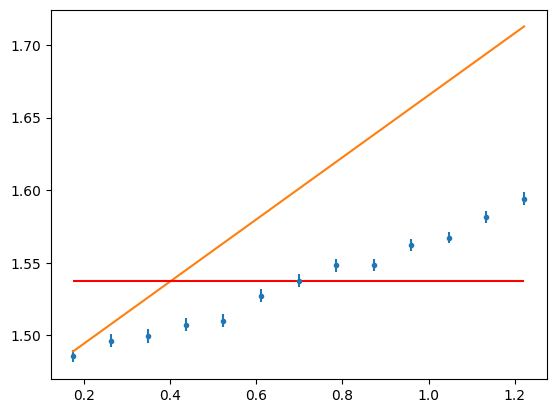

In [228]:
calibrate(phi1, psio, alpha, phi1_err, psio_err)

### Расчет $n_o, n_e$ по необыкновенной волне

$$
n(\theta) = n_e + (n_o − n_e ) \cos^2 \theta
$$
Задание 3. Найдие $n_o, n_e$ по данным для необыкновеной волны

In [229]:
def calculate(n: Numeric, cos_theta: Numeric, sigma_n: Numeric) -> tuple:
    base, slope, chi2, cov = fit_line(cos_theta**2, n**(-2), sigma_n * 2.0 / (n**3))
    ne = 1.0 / math.sqrt(base)
    neErr = math.sqrt(cov[1][1]) * 0.5 * (ne**3.0)
    no = 1.0 / math.sqrt(slope + base)
    noErr = math.sqrt(cov[1][1] / 4.0 / base + cov[0][0] / 4.0 / abs(slope) + math.sqrt(cov[0][1] * cov[1][0] / base / abs(slope)) / 2.0)
    return no, noErr, ne, neErr, chi2/n.size

In [230]:
def analyze(phi1, psie, alpha: float, phi1_err: float, psi_err: float):
    phi1 = np.array(phi1)
    psie = np.array(psie)
    n = refractive_index(phi1, psie, alpha)
    cos_t = cos_theta(phi1, n)
    sigma_n = n_err(phi1, psie, n, alpha, phi1_err, psi_err) 
    print(calculate(n, cos_t, sigma_n))
    

In [231]:
analyze(phi1, psie, alpha, phi1_err, psie_err)

(1.805508433834582, 0.0114259068927003, 1.6522876152051418, 0.00213405735671144, np.float64(1.7254650552542723))
